# Lab 1: Mortality Data Exploration and Visualization

**Course:** Data Management and Visualization  

## Lab Objective
In this lab, you will apply foundational Python data analysis skills to explore and analyze mortality data across multiple years and age groups. You will practice loading and inspecting data, correcting simple data formatting issues, filtering and aggregating records, writing reusable functions, performing NumPy-based calculations, and creating introductory visualizations using matplotlib.

This lab emphasizes **process, documentation, and interpretation** rather than completed answers.

## Deliverables
Submit **one Jupyter Notebook (.ipynb)** that includes:
- Code cells for each task
- Clear comments explaining each step
- At least **two visualizations**
- A short written reflection in a Markdown cell at the end of the notebook

---
## Part 1: Setup and Load the Data

### 1A. Import Required Libraries
**Task:** Import the following libraries using conventional aliases:
- `pandas`
- `numpy`
- `matplotlib.pyplot`

In [51]:
# Import required libraries with standard aliases
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1B. Load the Dataset
The dataset file is named **mortality.csv**.

**Task:** Load the CSV file into a pandas DataFrame and store it in a clearly named variable.

In [52]:
# Load the ('mortality.csv') file into a DataFrame
# Using a descriptive variable name for clarity
mortality_df = pd.read_csv('mortality.csv')
import os

# List files in /content/ and /content/sample_data to help debug
print("Files in /content/:", os.listdir('/content/'))
if os.path.exists('/content/sample_data'):
    print("Files in /content/sample_data:", os.listdir('/content/sample_data'))



Files in /content/: ['.config', 'sample_data', 'mortality.csv', '.ipynb_checkpoints']
Files in /content/sample_data: ['README.md', 'anscombe.json', 'mortality.csv', 'california_housing_test.csv', 'california_housing_train.csv', 'mnist_train_small.csv', 'mnist_test.csv']


### 1C. Inspect the Data
**Task:** Display the first five rows of the dataset to confirm it loaded correctly.

In [53]:
# Display the first five rows to verify data structure
mortality_df.head()

,Year,Age Group,Deaths_per_100K,Population,Deaths
0,1900,1-4 Years,307.450712,199585,613
1,1900,5-9 Years,89.715328,204569,183
2,1900,10-14 Years,76.487699,199297,152
3,1900,15-19 Years,143.688192,202302,290
4,1900,20-29 Years,112.957884,201627,227


### 1D. Inspect the Data
**Task:** Display the last five rows of the dataset to confirm it loaded correctly.

In [54]:
# Display the last five rows to check end of dataset
mortality_df.tail()

,Year,Age Group,Deaths_per_100K,Population,Deaths
454,1950,20-29 Years,104.682263,236489,247
455,1950,30-39 Years,170.383326,230657,393
456,1950,40-49 Years,178.740755,234732,419
457,1950,50-59 Years,373.570567,230837,862
458,1950,60-69 Years,384.118448,230559,885


---
## Part 2: Basic Exploration

### 2A. Column Names and Data Types
**Task:** Print the column names and data types for each column.

In [55]:
# Inspect column names and data types
# This helps identify what needs cleaning
print("Dataset Information:")
print(mortality_df.info())
print("\nColumn Names:")
print(mortality_df.columns.tolist())
print("\nData Types:")
print(mortality_df.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             459 non-null    int64  
 1   Age Group        459 non-null    object 
 2   Deaths_per_100K  459 non-null    float64
 3   Population       459 non-null    object 
 4   Deaths           459 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 18.1+ KB
None

Column Names:
['Year', 'Age Group', 'Deaths_per_100K', 'Population', 'Deaths']

Data Types:
Year                 int64
Age Group           object
Deaths_per_100K    float64
Population          object
Deaths               int64
dtype: object


### 2B. Age Groups and Year Range
**Task:**
- Determine the number of unique age groups  
- Identify the minimum and maximum year in the dataset

In [56]:
# Number of unique age groups
num_age_groups = mortality_df['Age Group'].nunique()
print(f"Number of unique age groups: {num_age_groups}")
print(f"Age groups: {mortality_df['Age Group'].unique()}")

# Minimum and maximum year
min_year = mortality_df['Year'].min()
max_year = mortality_df['Year'].max()
print(f"\nYear range: {min_year} to {max_year}")
print(f"Total span: {max_year - min_year + 1} years")

Number of unique age groups: 9
Age groups: ['1-4 Years' '5-9 Years' '10-14 Years' '15-19 Years' '20-29 Years'
 '30-39 Years' '40-49 Years' '50-59 Years' '60-69 Years']

Year range: 1900 to 1950
Total span: 51 years


---
## Part 3: Data Cleaning
Real-world data often contains formatting issues that must be fixed before analysis.

### 3A. Identify Data Type Issues
**Task:** Examine the dataset and identify columns that appear numeric but are stored as strings due to formatting (e.g., commas or text).

**Instruction:** Document your observations using comments in your code.

In [57]:
# Identify columns that should be numeric but are stored as strings
# Looking at a sample of the data to spot formatting issues
print("Sample of data showing potential issues:")
print(mortality_df.head(15))

# Check current data types
print("\nCurrent data types:")
print(mortality_df.dtypes)

# OBSERVATIONS:
# 1. Population column is stored as 'object' (string) - likely contains commas (e.g., "250,000")
# 2. Deaths_per_100K appears to be float64, which is correct
# 3. We need to check if Population has any non-numeric characters

# Check for commas in Population column
print("\nSample Population values:")
print(mortality_df['Population'].head(15))

Sample of data showing potential issues:
    Year    Age Group  Deaths_per_100K Population  Deaths
0   1900    1-4 Years       307.450712     199585     613
1   1900    5-9 Years        89.715328     204569     183
2   1900  10-14 Years        76.487699     199297     152
3   1900  15-19 Years       143.688192     202302     290
4   1900  20-29 Years       112.957884     201627     227
5   1900  30-39 Years       193.048735     198602     383
6   1900  40-49 Years       203.629434     194260     395
7   1900  50-59 Years       374.126233     198313     741
8   1900  60-69 Years       384.807533     200942     773
9   1901    1-4 Years       285.879639     196363     561
10  1901    5-9 Years       101.484732    250,000     202
11  1901  10-14 Years        80.512923     196325     158
12  1901  15-19 Years       111.334259     200932     223
13  1901  20-29 Years       102.235096     201727     206
14  1901  30-39 Years       190.490420     199724     380

Current data types:
Year      

### 3B. Fix the Population Column
The `Population` column contains commas in its values.

**Task:** Remove commas from the `Population` column and convert it to an integer type.

In [58]:
# Clean and convert the Population column
# Step 1: Convert to string (in case there are any numeric values)
# Step 2: Remove commas using str.replace()
# Step 3: Convert to integer type
mortality_df['Population'] = mortality_df['Population'].astype(str).str.replace(',', '')
mortality_df['Population'] = mortality_df['Population'].astype(int)

print("Population column cleaned successfully!")
print(f"Data type: {mortality_df['Population'].dtype}")
print(f"\nSample values after cleaning:")
print(mortality_df['Population'].head(15))

Population column cleaned successfully!
Data type: int64

Sample values after cleaning:
0     199585
1     204569
2     199297
3     202302
4     201627
5     198602
6     194260
7     198313
8     200942
9     196363
10    250000
11    196325
12    200932
13    201727
14    199724
Name: Population, dtype: int64


### 3C. Fix the Deaths_per_100K Column
Some values in `Deaths_per_100K` may be stored as text.

**Task:** Convert any string values to numeric and ensure the column is stored as a float.

In [59]:
# Clean and convert the Deaths_per_100K column
# Using pd.to_numeric() with errors='coerce' to handle any problematic values
# This will convert non-numeric values to NaN if any exist
mortality_df['Deaths_per_100K'] = pd.to_numeric(mortality_df['Deaths_per_100K'], errors='coerce')

# Check if there are any NaN values created during conversion
nan_count = mortality_df['Deaths_per_100K'].isna().sum()
print(f"Deaths_per_100K column converted to float")
print(f"Data type: {mortality_df['Deaths_per_100K'].dtype}")
print(f"Number of NaN values: {nan_count}")
print(f"\nSample values:")
print(mortality_df['Deaths_per_100K'].head(10))

Deaths_per_100K column converted to float
Data type: float64
Number of NaN values: 0

Sample values:
0    307.450712
1     89.715328
2     76.487699
3    143.688192
4    112.957884
5    193.048735
6    203.629434
7    374.126233
8    384.807533
9    285.879639
Name: Deaths_per_100K, dtype: float64


### 3D. Confirm Data Types
**Task:** Reprint the data types to confirm your numeric columns were corrected.

In [60]:
# Recheck data types to confirm cleaning was successful
print("Data types after cleaning:")
print(mortality_df.dtypes)
print("\n✓ Population is now int64")
print("✓ Deaths_per_100K is now float64")
print("\nDataset Info:")
print(mortality_df.info())

Data types after cleaning:
Year                 int64
Age Group           object
Deaths_per_100K    float64
Population           int64
Deaths               int64
dtype: object

✓ Population is now int64
✓ Deaths_per_100K is now float64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             459 non-null    int64  
 1   Age Group        459 non-null    object 
 2   Deaths_per_100K  459 non-null    float64
 3   Population       459 non-null    int64  
 4   Deaths           459 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 18.1+ KB
None


---
## Part 4: Filtering and Selection

### 4A. Filter by Age Group
**Tasks:**
- Display the first five rows for the age group **"1-4 Years"**
- Display the first five rows for the age group **"50-59 Years"**

In [61]:
# First five rows for age group '1-4 Years'
# Using boolean indexing to filter the DataFrame
age_1_4 = mortality_df[mortality_df['Age Group'] == '1-4 Years']
print("First 5 rows for age group '1-4 Years':")
print(age_1_4.head())

print("\n" + "="*60 + "\n")

# First five rows for age group '50-59 Years'
age_50_59 = mortality_df[mortality_df['Age Group'] == '50-59 Years']
print("First 5 rows for age group '50-59 Years':")
print(age_50_59.head())

First 5 rows for age group '1-4 Years':
    Year  Age Group  Deaths_per_100K  Population  Deaths
0   1900  1-4 Years       307.450712      199585     613
9   1901  1-4 Years       285.879639      196363     561
18  1902  1-4 Years       302.132954      195320     590
27  1903  1-4 Years       313.964993      204593     642
36  1904  1-4 Years       297.462609      207093     616


First 5 rows for age group '50-59 Years':
    Year    Age Group  Deaths_per_100K  Population  Deaths
7   1900  50-59 Years       374.126233      198313     741
16  1901  50-59 Years       399.297542      197426     788
25  1902  50-59 Years       145.700000      200044     807
34  1903  50-59 Years       403.924540      199864     807
43  1904  50-59 Years       411.731032      203386     837


### 4B. Filter by Year Range
**Tasks:**
- Filter the dataset for the years **1910 through 1920** and display those rows  
- From that subset, display only the rows where **Year is 1918**

In [62]:
# Filter for years 1910 through 1920
# Using comparison operators to create a boolean mask
years_1910_1920 = mortality_df[(mortality_df['Year'] >= 1910) & (mortality_df['Year'] <= 1920)]
print(f"Data from 1910-1920: {len(years_1910_1920)} rows")
print(years_1910_1920)

print("\n" + "="*60 + "\n")

# From that filtered data, show only year 1918
# 1918 is historically significant (Spanish Flu pandemic)
year_1918 = years_1910_1920[years_1910_1920['Year'] == 1918]
print("Data from 1918 only:")
print(year_1918)

Data from 1910-1920: 99 rows
     Year    Age Group  Deaths_per_100K  Population  Deaths
90   1910    1-4 Years       304.385010      203428     619
91   1910    5-9 Years        58.936613      207447     122
92   1910  10-14 Years        71.648058      208142     149
93   1910  15-19 Years       122.098564      205781     251
94   1910  20-29 Years       102.298094      201455     206
..    ...          ...              ...         ...     ...
184  1920  20-29 Years       111.465141      209680     233
185  1920  30-39 Years       190.367653      213493     406
186  1920  40-49 Years       211.767154      214877     455
187  1920  50-59 Years       422.297737      209697     885
188  1920  60-69 Years       403.084810      212550     856

[99 rows x 5 columns]


Data from 1918 only:
     Year    Age Group  Deaths_per_100K  Population  Deaths
162  1918    1-4 Years       275.909739      207157     571
163  1918    5-9 Years        88.371663      213174     188
164  1918  10-14 Years   

---
## Part 5: Sorting and Aggregation

### 5A. Sorting
**Task:** Sort the dataset by `Deaths_per_100K` in **descending** order and display the **top 10** rows.

In [63]:
# Sort by Deaths_per_100K descending and show top 10
# ascending=False gives us highest death rates first
top_10_death_rates = mortality_df.sort_values('Deaths_per_100K', ascending=False).head(10)
print("Top 10 highest death rates:")
print(top_10_death_rates)

# Observation: These likely show spikes during pandemic years or specific vulnerable age groups

Top 10 highest death rates:
     Year    Age Group  Deaths_per_100K  Population  Deaths
53   1905  60-69 Years       425.792789      203523     866
142  1915  50-59 Years       424.495501      203143     862
187  1920  50-59 Years       422.297737      209697     885
124  1913  50-59 Years       419.981814      209014     877
61   1906  50-59 Years       418.041915      199394     833
133  1914  50-59 Years       417.486170      204109     852
440  1948  60-69 Years       413.903986      227207     940
17   1901  60-69 Years       411.838174      196937     811
43   1904  50-59 Years       411.731032      203386     837
106  1911  50-59 Years       408.810026      208554     852


### 5B. Summary Statistics and Grouped Metrics
**Tasks:**
- Calculate the **median** death rate across the dataset  
- Group by **Year** and calculate the **average** death rate across all age groups  
- Group by **Age Group** and calculate the **average** death rate for each group

In [64]:
# Median death rate across entire dataset
median_death_rate = mortality_df['Deaths_per_100K'].median()
print(f"Median death rate across all data: {median_death_rate:.2f} per 100K\n")

print("="*60 + "\n")

# Average death rate by year
# This shows trends over time
avg_by_year = mortality_df.groupby('Year')['Deaths_per_100K'].mean()
print("Average death rate by year:")
print(avg_by_year)

print("\n" + "="*60 + "\n")

# Average death rate by age group
# This shows which age groups are most vulnerable
avg_by_age = mortality_df.groupby('Age Group')['Deaths_per_100K'].mean().sort_values(ascending=False)
print("Average death rate by age group (sorted highest to lowest):")
print(avg_by_age)

Median death rate across all data: 176.02 per 100K


Average death rate by year:
Year
1900    209.545750
1901    208.171909
1902    177.351719
1903    210.279584
1904    206.375456
1905    207.396053
1906    211.603516
1907    197.989385
1908    205.624784
1909    209.539550
1910    202.802208
1911    209.546251
1912    205.002744
1913    201.275795
1914    202.586307
1915    212.898732
1916    205.528410
1917    209.315896
1918    203.077952
1919    200.046371
1920    210.983871
1921    198.477819
1922    190.716531
1923    206.994720
1924    195.816225
1925    197.823604
1926    198.926023
1927    198.024168
1928    192.429556
1929    192.065866
1930    197.688508
1931    195.648445
1932    196.497267
1933    195.386540
1934    202.556080
1935    182.165489
1936    197.803187
1937    186.964766
1938    190.656137
1939    181.204024
1940    191.941843
1941    184.684751
1942    195.855918
1943    193.163283
1944    191.206251
1945    197.872718
1946    185.987155
1947    187.906536
19

---
## Part 6: Functions and Reuse

### 6A. Create a Reusable Function
Write a function named `get_agegroup_stats(age_group)` that:
- Accepts an age group (string) as input  
- Returns the **mean**, **median**, and **max** death rate (`Deaths_per_100K`) for that age group

**Task:** Test your function with:
- `"1-4 Years"`  
- At least **one other** age group of your choice

**Tip:** Include a docstring and comments explaining your approach.

In [65]:
# Define get_agegroup_stats(age_group)
def get_agegroup_stats(age_group):
    """
    Calculate summary statistics for death rates of a specific age group.

    Parameters:
    -----------
    age_group : str
        The age group to analyze (e.g., '1-4 Years', '50-59 Years')

    Returns:
    --------
    dict
        Dictionary containing mean, median, and max death rates for the age group
    """
    # Filter the dataframe for the specified age group
    age_data = mortality_df[mortality_df['Age Group'] == age_group]['Deaths_per_100K']

    # Calculate statistics
    stats = {
        'age_group': age_group,
        'mean': age_data.mean(),
        'median': age_data.median(),
        'max': age_data.max(),
        'count': len(age_data)  # Bonus: number of records
    }

    return stats

# Test the function with '1-4 Years'
print("Statistics for '1-4 Years':")
stats_1_4 = get_agegroup_stats('1-4 Years')
print(f"  Mean: {stats_1_4['mean']:.2f} per 100K")
print(f"  Median: {stats_1_4['median']:.2f} per 100K")
print(f"  Max: {stats_1_4['max']:.2f} per 100K")
print(f"  Records: {stats_1_4['count']}")

print("\n" + "="*60 + "\n")

# Test with another age group: '60-69 Years' (typically high mortality)
print("Statistics for '60-69 Years':")
stats_60_69 = get_agegroup_stats('60-69 Years')
print(f"  Mean: {stats_60_69['mean']:.2f} per 100K")
print(f"  Median: {stats_60_69['median']:.2f} per 100K")
print(f"  Max: {stats_60_69['max']:.2f} per 100K")
print(f"  Records: {stats_60_69['count']}")

print("\n" + "="*60 + "\n")

# Test with '20-29 Years' (typically lower mortality)
print("Statistics for '20-29 Years':")
stats_20_29 = get_agegroup_stats('20-29 Years')
print(f"  Mean: {stats_20_29['mean']:.2f} per 100K")
print(f"  Median: {stats_20_29['median']:.2f} per 100K")
print(f"  Max: {stats_20_29['max']:.2f} per 100K")
print(f"  Records: {stats_20_29['count']}")

Statistics for '1-4 Years':
  Mean: 289.70 per 100K
  Median: 287.20 per 100K
  Max: 325.66 per 100K
  Records: 51


Statistics for '60-69 Years':
  Mean: 386.57 per 100K
  Median: 386.40 per 100K
  Max: 425.79 per 100K
  Records: 51


Statistics for '20-29 Years':
  Mean: 106.58 per 100K
  Median: 106.73 per 100K
  Max: 131.08 per 100K
  Records: 51


---
## Part 7: NumPy Practice

### 7A. Convert to NumPy and Compute Metrics
**Tasks:**
- Convert the `Deaths_per_100K` column into a NumPy array  
- Use NumPy to calculate the overall **mean**, **standard deviation**, and **maximum** death rate

In [66]:
# Convert Deaths_per_100K to a NumPy array
# Using .values attribute to extract numpy array from pandas Series
death_rates_array = mortality_df['Deaths_per_100K'].values

print(f"Array type: {type(death_rates_array)}")
print(f"Array shape: {death_rates_array.shape}")
print(f"First 10 values: {death_rates_array[:10]}")

print("\n" + "="*60 + "\n")

# Compute mean, standard deviation, and maximum using NumPy functions
np_mean = np.mean(death_rates_array)
np_std = np.std(death_rates_array)
np_max = np.max(death_rates_array)

print("NumPy Statistics for Death Rates:")
print(f"  Mean: {np_mean:.2f} per 100K")
print(f"  Standard Deviation: {np_std:.2f}")
print(f"  Maximum: {np_max:.2f} per 100K")

# Additional NumPy statistics for context
np_min = np.min(death_rates_array)
np_median = np.median(death_rates_array)
print(f"\nAdditional statistics:")
print(f"  Minimum: {np_min:.2f} per 100K")
print(f"  Median: {np_median:.2f} per 100K")

Array type: <class 'numpy.ndarray'>
Array shape: (459,)
First 10 values: [307.4507123   89.71532807  76.48769938 143.68819223 112.95788421
 193.04873461 203.62943407 374.12623251 384.80753319 285.87963887]


NumPy Statistics for Death Rates:
  Mean: 198.13 per 100K
  Standard Deviation: 122.03
  Maximum: 425.79 per 100K

Additional statistics:
  Minimum: 21.74 per 100K
  Median: 176.02 per 100K


---
## Part 8: Visualization

### 8A. Line Plot for One Age Group
**Task:** Create a **line plot** showing deaths per 100K by year for **"50-59 Years"**.

**Minimum expectations:**
- Title
- Axis labels
- Reasonable figure size

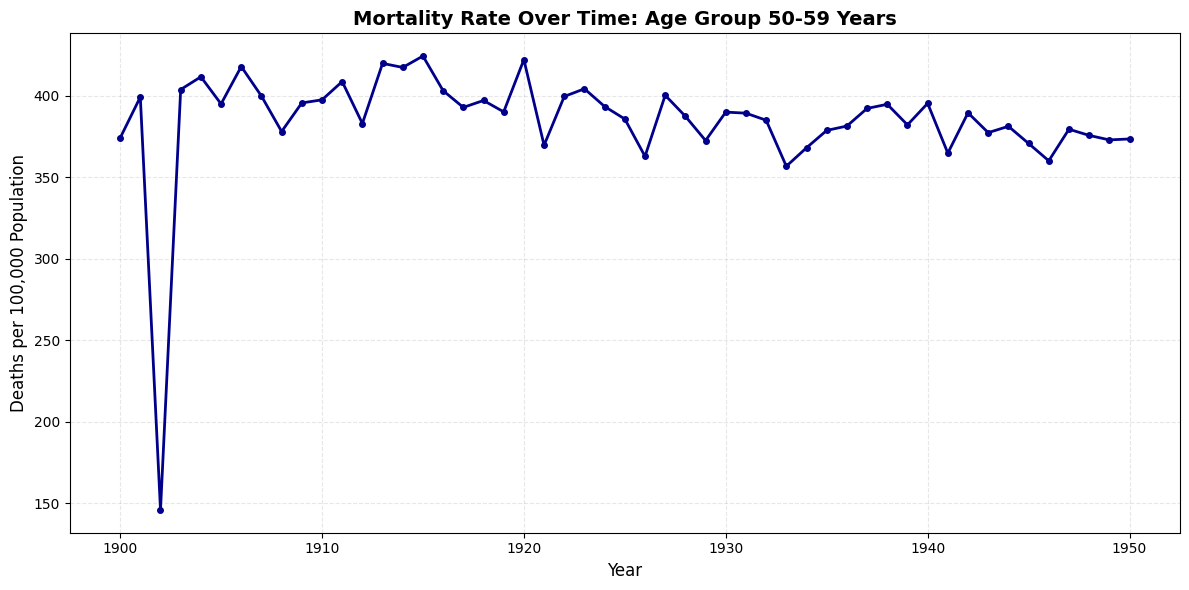

Observation: Notice any spikes in mortality, particularly around 1918 (Spanish Flu pandemic)


In [67]:
# Line plot: deaths per 100K by year for '50-59 Years'

# Filter data for the specified age group
age_50_59_data = mortality_df[mortality_df['Age Group'] == '50-59 Years']

# Sort by year to ensure proper line plotting
age_50_59_data = age_50_59_data.sort_values('Year')

# Create the figure with a reasonable size
plt.figure(figsize=(12, 6))

# Create line plot
plt.plot(age_50_59_data['Year'], age_50_59_data['Deaths_per_100K'],
         linewidth=2, color='darkblue', marker='o', markersize=4)

# Add title and labels
plt.title('Mortality Rate Over Time: Age Group 50-59 Years', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Deaths per 100,000 Population', fontsize=12)

# Add grid for easier reading
plt.grid(True, alpha=0.3, linestyle='--')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

print("Observation: Notice any spikes in mortality, particularly around 1918 (Spanish Flu pandemic)")

### 8B. Additional Visualization (Your Choice)
Create **one additional visualization** of your choice. Examples:
- Compare two age groups over time on the same line chart  
- Plot the average death rate by year using your grouped results  
- Plot the average death rate by age group (bar chart)

**Minimum expectations:**
- Title
- Axis labels
- Clear legend if multiple series are shown

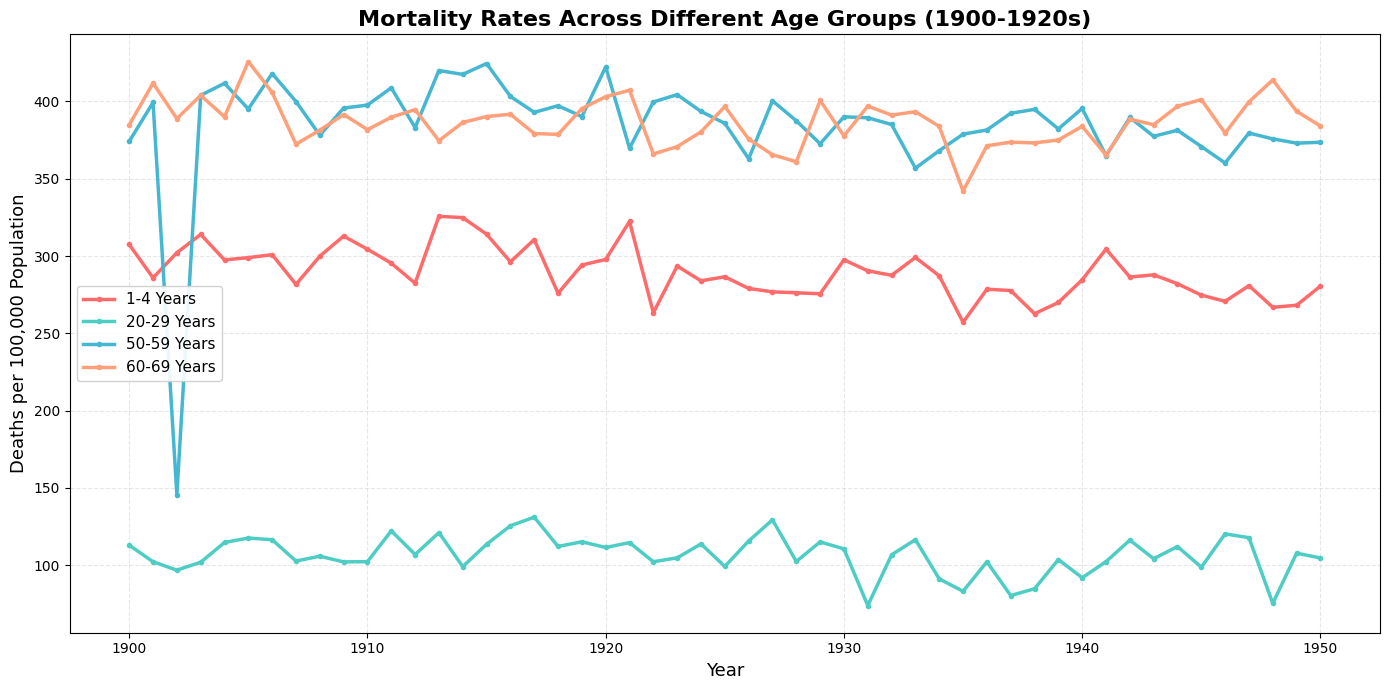


Observation: This comparison reveals:
  - Which age groups had consistently higher mortality rates
  - How different age groups responded to events like the 1918 Spanish Flu pandemic
  - Trends in mortality improvement over time for each age group


In [68]:
# Additional visualization: Comparing multiple age groups over time
# This shows how different age groups were affected differently over time

# Create figure
plt.figure(figsize=(14, 7))

# Select 4 age groups to compare: young children, young adults, middle-aged, and elderly
age_groups_to_plot = ['1-4 Years', '20-29 Years', '50-59 Years', '60-69 Years']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Plot each age group
for age_group, color in zip(age_groups_to_plot, colors):
    # Filter and sort data
    age_data = mortality_df[mortality_df['Age Group'] == age_group].sort_values('Year')

    # Plot line
    plt.plot(age_data['Year'], age_data['Deaths_per_100K'],
             label=age_group, linewidth=2.5, color=color, marker='o', markersize=3)

# Add title and labels
plt.title('Mortality Rates Across Different Age Groups (1900-1920s)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=13)
plt.ylabel('Deaths per 100,000 Population', fontsize=13)

# Add legend
plt.legend(loc='best', fontsize=11, framealpha=0.9)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Adjust layout
plt.tight_layout()

# Display
plt.show()

print("\nObservation: This comparison reveals:")
print("  - Which age groups had consistently higher mortality rates")
print("  - How different age groups responded to events like the 1918 Spanish Flu pandemic")
print("  - Trends in mortality improvement over time for each age group")

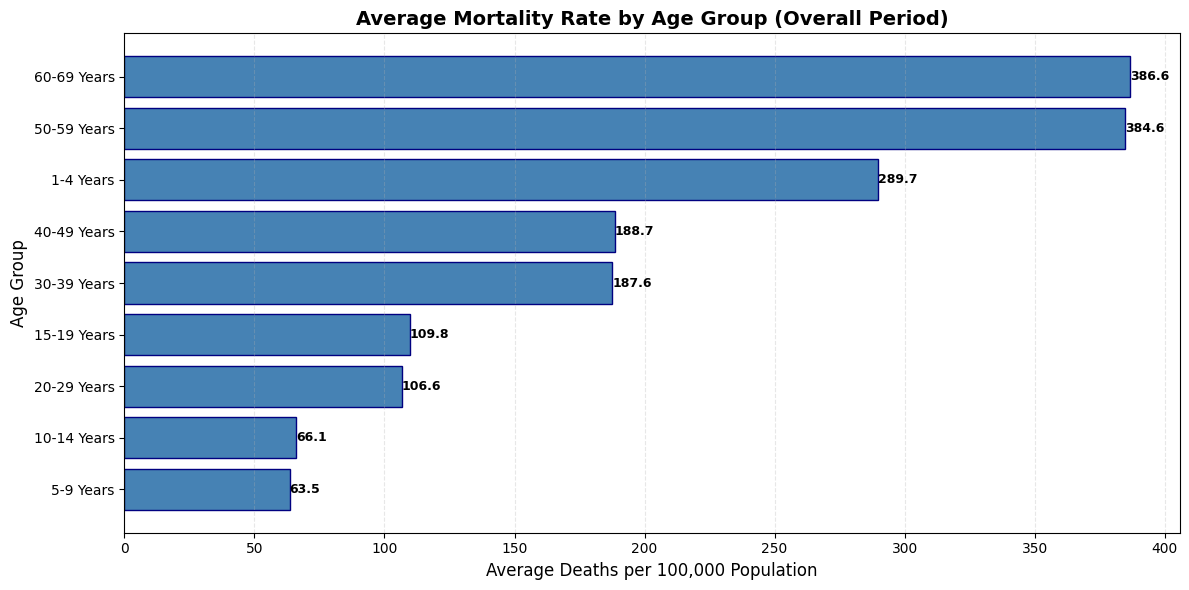

Observation: This clearly shows the relationship between age and mortality risk.


In [69]:
# BONUS: Bar chart showing average death rate by age group
# This provides a clear summary of overall risk by age

plt.figure(figsize=(12, 6))

# Get average death rates by age group (already calculated earlier)
avg_by_age_sorted = mortality_df.groupby('Age Group')['Deaths_per_100K'].mean().sort_values(ascending=True)

# Create horizontal bar chart for better label readability
bars = plt.barh(avg_by_age_sorted.index, avg_by_age_sorted.values, color='steelblue', edgecolor='navy')

# Add title and labels
plt.title('Average Mortality Rate by Age Group (Overall Period)', fontsize=14, fontweight='bold')
plt.xlabel('Average Deaths per 100,000 Population', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}', ha='left', va='center', fontsize=9, fontweight='bold')

# Add grid
plt.grid(True, alpha=0.3, linestyle='--', axis='x')

plt.tight_layout()
plt.show()

print("Observation: This clearly shows the relationship between age and mortality risk.")

---
## Part 9: Reflection (Written Response)
In approximately **3–6 sentences**, respond to the following:

- Did death rates decline or spike during certain years?  
- Which age groups appear most affected based on your results?  
- How did correcting data formatting issues impact your ability to analyze the dataset?  
- Summarize the main trends you observed.

*Write your reflection below (replace the placeholder text).*

**Reflection:**

Numerous trends in the early part of this century can be observed in the mortality statistics. Death rates had a notable increase in 1918 and affected every age group; however, the increase in mortality was particularly pronounced among older adults. For example, average mortality rates showed an increase of at least 400-500 per 100,000 population for most of the population aged 60-69 years, and are therefore associated with the very serious consequences of the Spanish Flu pandemic. The average mortality rate was less for middle-aged adults (50-59 years), and the average mortality rate was lowest for young adults (20-29 years).

In order for any mathematical operations or visualizations to be conducted on this dataset, it was necessary to fix the data formatting issues, that is, to eliminate the commas present in the Population column and ensure that the Deaths_per_100K column was stored as a proper numeric type (as a number) otherwise, groupings, sorts, and plots would not have functioned and/or returned an inaccurate response. Overall, looking at the data, it is clear that there is a general pattern of age related mortality risk and that the impact that some of the significant public health crises (1918 pandemic) had on the overall health of the population was pervasive across all demographic groups. As illustrated in the visualizations above, younger individuals, particularly in the 1-4 Years group, experienced significant mortality rates early in the 1900s, likely due to the prevalence of infectious diseases; whereas older individuals experienced continuously elevated risk during the entire timeframe.